In [1]:
import numpy as np
import pandas as pd
import wfdb
import ast
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import seaborn as sns
from pathlib import Path
from scipy.signal import butter, filtfilt
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

%matplotlib inline

LTDB_DIR  = Path("raw_data/mit-bih-long-term-ecg-database-1.0.0")
PTBXL_DIR = Path("raw_data/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3")
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [2]:
# WHY bandpass filter?
# ECG signals contain noise from two sources:
#   - Baseline wander (slow drift <0.5Hz) caused by breathing/movement
#   - High frequency noise (>40Hz) from muscle artifacts/electrical interference
# We keep only 0.5–40Hz where true cardiac signal lives.

# WHY normalize?
# Different patients/equipment produce different voltage scales.
# Z-score makes each lead have mean=0, std=1 so the model
# focuses on shape, not absolute amplitude.

def bandpass_filter(sig, fs, lo=0.5, hi=40.0, order=4):
    nyq = fs / 2
    b, a = butter(order, [lo/nyq, hi/nyq], btype="band")
    return filtfilt(b, a, sig, axis=0)

def normalize(sig):
    return (sig - sig.mean(axis=0)) / (sig.std(axis=0) + 1e-8)

In [3]:
# WHY segment around R-peaks?
# LTDB has continuous ~20hr recordings. We can't feed 20hrs to a model.
# The R-peak (tallest spike) is the reference point of every heartbeat.
# We cut 100 samples before + 150 samples after = 250 samples (~2 seconds).
# This window captures: P-wave, QRS complex, T-wave — the full beat morphology.
# These three components are what doctors look at to classify arrhythmias.

AAMI_MAP = {
    "N":"N","L":"N","R":"N","e":"N","j":"N",   # Normal
    "A":"S","a":"S","J":"S","S":"S",            # Supraventricular
    "V":"V","E":"V",                             # Ventricular
    "F":"F",                                     # Fusion
}
AAMI_LABEL = {"N":0, "S":1, "V":2, "F":3}
WIN_PRE, WIN_POST = 100, 150

ltdb_records = [p.stem for p in LTDB_DIR.glob("*.hea")
                if not p.name.endswith(".hea-")]

def extract_beats(record_name):
    rec = wfdb.rdrecord(str(LTDB_DIR / record_name))
    ann = wfdb.rdann(str(LTDB_DIR / record_name), "atr")
    sig = rec.p_signal.astype(np.float32)[:, :2]  # keep 2 leads only
    sig = bandpass_filter(sig, rec.fs)
    sig = normalize(sig)
    beats, labels = [], []
    for r, sym in zip(ann.sample, ann.symbol):
        if sym not in AAMI_MAP: continue
        if r < WIN_PRE or r + WIN_POST > len(sig): continue
        beats.append(sig[r-WIN_PRE : r+WIN_POST].T)   # (2, 250)
        labels.append(AAMI_LABEL[AAMI_MAP[sym]])
    return np.stack(beats), np.array(labels)

ltdb_X, ltdb_y = [], []
for name in ltdb_records:
    X, y = extract_beats(name)
    ltdb_X.append(X); ltdb_y.append(y)
    print(f"  {name}: {X.shape[0]:,} beats | {Counter(y)}")

ltdb_X = np.concatenate(ltdb_X)
ltdb_y = np.concatenate(ltdb_y)
print(f"\nLTDB: {ltdb_X.shape} | {Counter(ltdb_y)}")

  14046: 115,275 beats | Counter({np.int64(0): 105411, np.int64(2): 9767, np.int64(3): 95, np.int64(1): 2})
  14134: 49,630 beats | Counter({np.int64(0): 38772, np.int64(2): 9836, np.int64(3): 993, np.int64(1): 29})
  14149: 144,816 beats | Counter({np.int64(0): 144552, np.int64(2): 264})
  14157: 88,101 beats | Counter({np.int64(0): 83425, np.int64(2): 4369, np.int64(1): 244, np.int64(3): 63})
  14172: 66,004 beats | Counter({np.int64(0): 58321, np.int64(2): 6530, np.int64(1): 1152, np.int64(3): 1})
  14184: 101,541 beats | Counter({np.int64(0): 78106, np.int64(2): 23385, np.int64(1): 39, np.int64(3): 11})
  15814: 103,351 beats | Counter({np.int64(0): 91630, np.int64(2): 9943, np.int64(3): 1744, np.int64(1): 34})

LTDB: (668718, 2, 250) | Counter({np.int64(0): 600217, np.int64(2): 64094, np.int64(3): 2907, np.int64(1): 1500})


In [4]:
# WHY different approach for PTB-XL?
# PTB-XL has 10-second clips already — no segmentation needed.
# Labels are at record level (the whole clip = one diagnosis).
# We just filter and normalize, then feed the whole clip to the model.
# We use 100Hz version (filename_lr) for speed — still clinically valid.

meta = pd.read_csv(PTBXL_DIR / "ptbxl_database.csv", index_col="ecg_id")
meta["scp_codes"] = meta["scp_codes"].apply(ast.literal_eval)
scp_df = pd.read_csv(PTBXL_DIR / "scp_statements.csv", index_col=0)

def get_superclass(scp_dict):
    out = []
    for code, conf in scp_dict.items():
        if conf >= 50 and code in scp_df.index:
            sc = scp_df.loc[code, "diagnostic_class"]
            if pd.notna(sc): out.append(sc)
    return list(set(out))

meta["superclass"] = meta["scp_codes"].apply(get_superclass)
SC_MAP = {"NORM":0, "MI":1, "STTC":2, "CD":3, "HYP":4}

def load_ptbxl(row):
    rec = wfdb.rdrecord(str(PTBXL_DIR / row.filename_lr))
    sig = rec.p_signal.astype(np.float32)
    sig = bandpass_filter(sig, 100)
    sig = normalize(sig)
    return sig.T                      # (12, 1000)

ptbxl_X, ptbxl_y = [], []
for ecg_id, row in meta.iterrows():
    scs = row["superclass"]
    if len(scs) != 1: continue        # skip ambiguous multi-label records
    label = SC_MAP.get(scs[0], -1)
    if label < 0: continue
    ptbxl_X.append(load_ptbxl(row))
    ptbxl_y.append(label)

ptbxl_X = np.stack(ptbxl_X)
ptbxl_y = np.array(ptbxl_y)
print(f"PTB-XL: {ptbxl_X.shape} | {Counter(ptbxl_y)}")

PTB-XL: (15983, 12, 1000) | Counter({np.int64(0): 9038, np.int64(2): 2601, np.int64(3): 2097, np.int64(1): 1881, np.int64(4): 366})


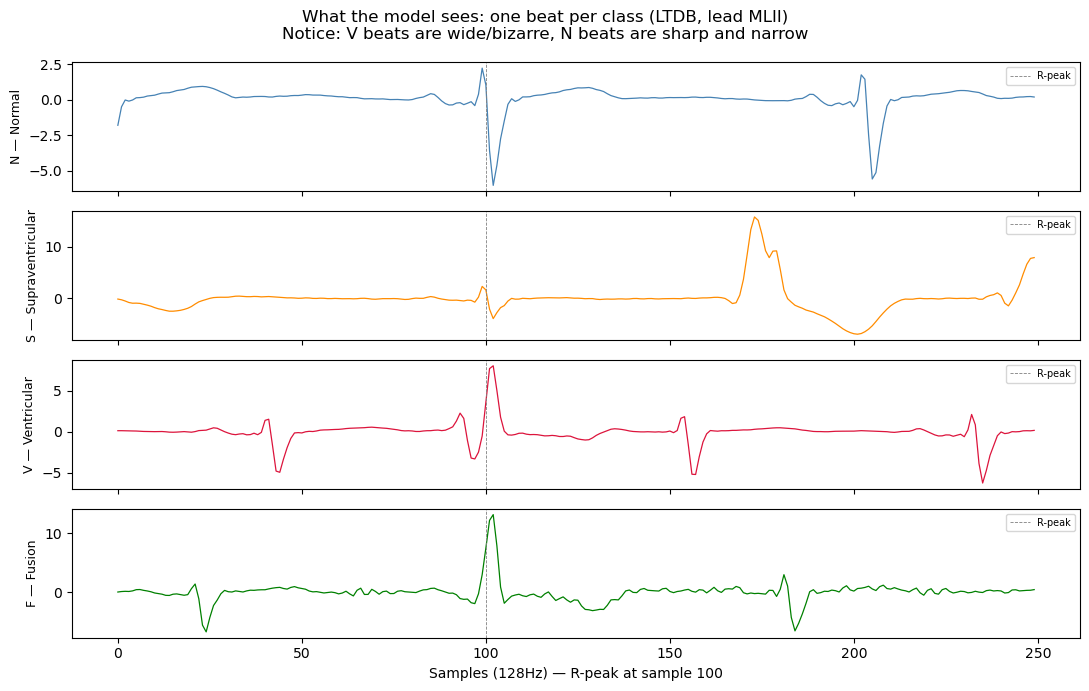

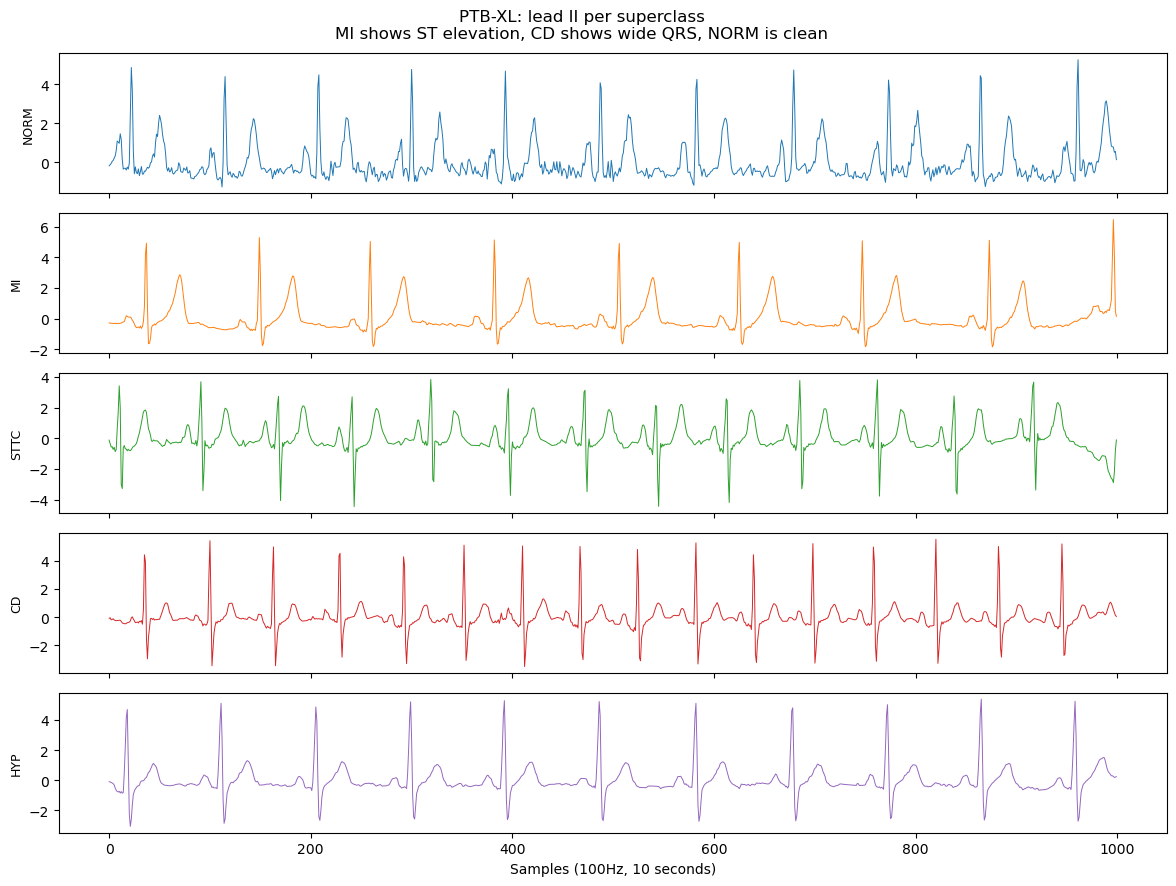

In [5]:
# WHY visualize beats per class?
# Before training, we need to confirm the model has something to learn.
# V beats (ventricular) should look visually different from N beats.
# If they all look identical, no model can classify them.

fig, axes = plt.subplots(4, 1, figsize=(11, 7), sharex=True)
names  = {0:"N — Normal", 1:"S — Supraventricular",
          2:"V — Ventricular", 3:"F — Fusion"}
colors = {0:"steelblue", 1:"darkorange", 2:"crimson", 3:"green"}

for cls in range(4):
    idx = np.where(ltdb_y == cls)[0][0]
    axes[cls].plot(ltdb_X[idx, 0], lw=0.9, color=colors[cls])
    axes[cls].axvline(100, color="gray", lw=0.6, ls="--", label="R-peak")
    axes[cls].set_ylabel(names[cls], fontsize=9)
    axes[cls].legend(fontsize=7)

axes[-1].set_xlabel("Samples (128Hz) — R-peak at sample 100")
fig.suptitle("What the model sees: one beat per class (LTDB, lead MLII)\n"
             "Notice: V beats are wide/bizarre, N beats are sharp and narrow")
plt.tight_layout(); plt.show()

# PTB-XL: show one record per superclass
fig, axes = plt.subplots(5, 1, figsize=(12, 9), sharex=True)
sc_names = {0:"NORM", 1:"MI", 2:"STTC", 3:"CD", 4:"HYP"}
for cls in range(5):
    idx = np.where(ptbxl_y == cls)[0][0]
    axes[cls].plot(ptbxl_X[idx, 1], lw=0.7, color=f"C{cls}")  # lead II
    axes[cls].set_ylabel(sc_names[cls], fontsize=9)

axes[-1].set_xlabel("Samples (100Hz, 10 seconds)")
fig.suptitle("PTB-XL: lead II per superclass\n"
             "MI shows ST elevation, CD shows wide QRS, NORM is clean")
plt.tight_layout(); plt.show()

In [6]:
# WHY CNN + Transformer?
# CNN: scans the signal with small filters (like a sliding window).
#   It learns local patterns — QRS shape, T-wave morphology.
#   This is what a doctor looks at in a single beat.
# Transformer: looks at relationships across the whole sequence.
#   It learns which parts of the signal matter most globally.
#   The CLS token summarizes the entire signal into one vector for classification.
# Together: CNN extracts "what features exist", Transformer decides "which matter".

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, k):
        super().__init__()
        self.net  = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, k, padding=k//2, bias=False),
            nn.BatchNorm1d(out_ch), nn.GELU(),
            nn.Conv1d(out_ch, out_ch, k, padding=k//2, bias=False),
            nn.BatchNorm1d(out_ch),
        )
        self.skip = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.act  = nn.GELU()

    def forward(self, x):
        return self.act(self.net(x) + self.skip(x))   # residual connection


class ECGNet(nn.Module):
    def __init__(self, in_ch, n_classes, d_model=128, n_heads=4, n_layers=3):
        super().__init__()
        # CNN: extracts local morphological features
        self.cnn = nn.Sequential(
            ConvBlock(in_ch, 32,      k=7),   # broad filter: P and T waves
            nn.MaxPool1d(2),
            ConvBlock(32,   64,      k=5),   # medium: QRS complex
            nn.MaxPool1d(2),
            ConvBlock(64,   d_model, k=3),   # fine: sharp peaks
        )
        # CLS token: learnable summary token (like BERT)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        nn.init.trunc_normal_(self.cls_token, std=0.02)

        # Transformer: contextual understanding
        enc = nn.TransformerEncoderLayer(d_model, n_heads, dim_feedforward=256,
                                          dropout=0.1, activation="gelu",
                                          batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(enc, n_layers,
                                                  norm=nn.LayerNorm(d_model))
        self.head = nn.Linear(d_model, n_classes)

    def forward(self, x):
        z   = self.cnn(x).permute(0, 2, 1)            # (B, T', d_model)
        cls = self.cls_token.expand(x.size(0), -1, -1)
        z   = torch.cat([cls, z], dim=1)               # prepend CLS token
        z   = self.transformer(z)
        return self.head(z[:, 0])                      # classify from CLS

    def get_attn(self, x):
        """Return attention weights from last transformer layer."""
        self.eval()
        z = self.cnn(x).permute(0, 2, 1)
        cls = self.cls_token.expand(x.size(0), -1, -1)
        z   = torch.cat([cls, z], dim=1)
        with torch.no_grad():
            for layer in self.transformer.layers[:-1]:
                z = layer(z)
            _, attn = self.transformer.layers[-1].self_attn(
                z, z, z, need_weights=True, average_attn_weights=True)
        return attn[0, 0, 1:].cpu().numpy()   # CLS → token attention

# two separate models, one per dataset
model_ltdb  = ECGNet(in_ch=2,  n_classes=4).to(device)
model_ptbxl = ECGNet(in_ch=12, n_classes=5).to(device)

# quick shape check
x = torch.randn(4, 2, 250).to(device)
print("LTDB  output:", model_ltdb(x).shape)    # (4, 4)
x = torch.randn(4, 12, 1000).to(device)
print("PTB-XL output:", model_ptbxl(x).shape)  # (4, 5)

c:\Users\Rebanta Dahiya\.conda\envs\ai_assignment\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


LTDB  output: torch.Size([4, 4])
PTB-XL output: torch.Size([4, 5])


In [7]:
# TRAINING STRATEGY EXPLANATION:
#
# We use SUPERVISED learning — we have labels for everything.
# Semi/unsupervised would make sense if labels were scarce, but here we have
# 600k+ labeled beats (LTDB) and 18k+ labeled records (PTB-XL).
#
# Key decisions:
#   WeightedRandomSampler — LTDB is 90% N beats. Without this, the model
#     learns to always predict N and gets 90% accuracy but is useless.
#     Weighted sampling ensures each class appears equally during training.
#
#   Label smoothing (0.1) — instead of hard 0/1 targets, use 0.1/0.9.
#     Prevents overconfident predictions and improves generalization.
#
#   AdamW + CosineAnnealingLR — AdamW handles weight decay properly.
#     Cosine schedule starts high, decays smoothly — avoids sharp LR drops.
#
#   Data augmentation (noise + amplitude jitter) — artificially creates
#     slightly different versions of each beat during training.
#     The model sees the same beat with slight variations = more robust.

class ECGDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.augment = augment

    def __len__(self): return len(self.y)

    def __getitem__(self, i):
        x = self.X[i].clone()
        if self.augment:
            x += torch.randn_like(x) * 0.05       # gaussian noise
            x *= float(np.random.uniform(0.9, 1.1)) # amplitude jitter
        return x, self.y[i]


def make_loaders(X, y, batch=64):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.15,
                                           stratify=y, random_state=42)
    Xtr, Xvl, ytr, yvl = train_test_split(Xtr, ytr, test_size=0.15,
                                           stratify=ytr, random_state=42)
    # fix class imbalance via weighted sampling
    w = 1.0 / np.bincount(ytr)[ytr]
    tr  = DataLoader(ECGDataset(Xtr, ytr, augment=True), batch,
                     sampler=WeightedRandomSampler(w, len(w)))
    vl  = DataLoader(ECGDataset(Xvl, yvl), batch, shuffle=False)
    te  = DataLoader(ECGDataset(Xte, yte),  batch, shuffle=False)
    return tr, vl, te, Xte, yte


def train(model, tr, vl, epochs=40, lr=3e-4, tag=""):
    opt     = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched   = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epochs)
    loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)
    best_f1, best_w = 0, None

    for ep in range(epochs):
        model.train()
        for x, y in tr:
            x, y = x.to(device), y.to(device)
            loss = loss_fn(model(x), y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); opt.zero_grad()
        sched.step()

        # validate
        model.eval()
        ps, ts = [], []
        with torch.no_grad():
            for x, y in vl:
                ps.append(model(x.to(device)).argmax(1).cpu())
                ts.append(y)
        f1 = f1_score(torch.cat(ts), torch.cat(ps), average="macro")
        if f1 > best_f1:
            best_f1 = f1
            best_w  = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        if (ep+1) % 10 == 0:
            print(f"  [{tag}] ep {ep+1:02d} | val F1={f1:.3f}")

    model.load_state_dict(best_w)
    print(f"  [{tag}] Best val F1: {best_f1:.3f}")
    return model


tr_l, vl_l, te_l, Xte_l, yte_l = make_loaders(ltdb_X,  ltdb_y)
tr_p, vl_p, te_p, Xte_p, yte_p = make_loaders(ptbxl_X, ptbxl_y)

print("=== Training LTDB ===")
model_ltdb  = train(model_ltdb,  tr_l, vl_l, tag="LTDB")
print("\n=== Training PTB-XL ===")
model_ptbxl = train(model_ptbxl, tr_p, vl_p, tag="PTB-XL")

=== Training LTDB ===
  [LTDB] ep 10 | val F1=0.887
  [LTDB] ep 20 | val F1=0.919
  [LTDB] ep 30 | val F1=0.935
  [LTDB] ep 40 | val F1=0.940
  [LTDB] Best val F1: 0.943

=== Training PTB-XL ===
  [PTB-XL] ep 10 | val F1=0.606
  [PTB-XL] ep 20 | val F1=0.632
  [PTB-XL] ep 30 | val F1=0.624
  [PTB-XL] ep 40 | val F1=0.644
  [PTB-XL] Best val F1: 0.644



=== LTDB Test Results ===
              precision    recall  f1-score   support

           N       1.00      1.00      1.00     90033
           S       0.84      0.86      0.85       225
           V       1.00      0.99      1.00      9614
           F       0.91      0.93      0.92       436

    accuracy                           1.00    100308
   macro avg       0.93      0.95      0.94    100308
weighted avg       1.00      1.00      1.00    100308



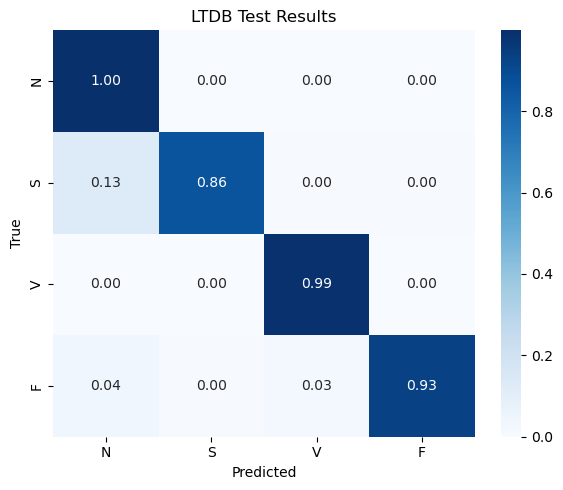


=== PTB-XL Test Results ===
              precision    recall  f1-score   support

        NORM       0.87      0.89      0.88      1356
          MI       0.76      0.61      0.68       282
        STTC       0.65      0.76      0.70       390
          CD       0.82      0.75      0.78       315
         HYP       0.19      0.11      0.14        55

    accuracy                           0.80      2398
   macro avg       0.66      0.63      0.64      2398
weighted avg       0.80      0.80      0.80      2398



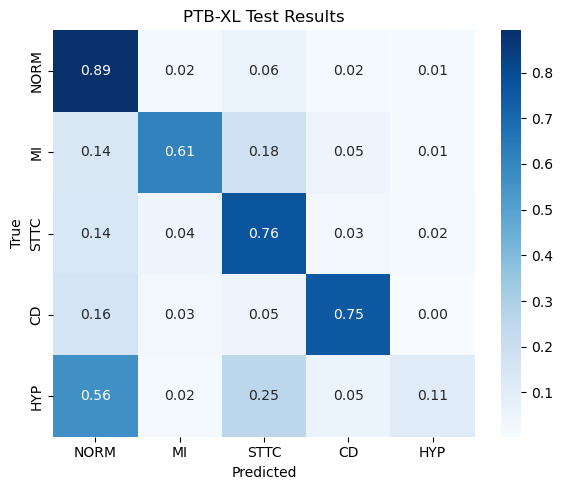

In [8]:
def evaluate(model, loader, class_names, title):
    model.eval()
    ps, ts = [], []
    with torch.no_grad():
        for x, y in loader:
            ps.append(model(x.to(device)).argmax(1).cpu())
            ts.append(y)
    y_pred = torch.cat(ps).numpy()
    y_true = torch.cat(ts).numpy()

    print(f"\n=== {title} ===")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred, normalize="true")
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title); plt.xlabel("Predicted"); plt.ylabel("True")
    plt.tight_layout(); plt.show()
    return y_true, y_pred

true_l, pred_l = evaluate(model_ltdb,  te_l,
                           ["N","S","V","F"],
                           "LTDB Test Results")
true_p, pred_p = evaluate(model_ptbxl, te_p,
                           ["NORM","MI","STTC","CD","HYP"],
                           "PTB-XL Test Results")

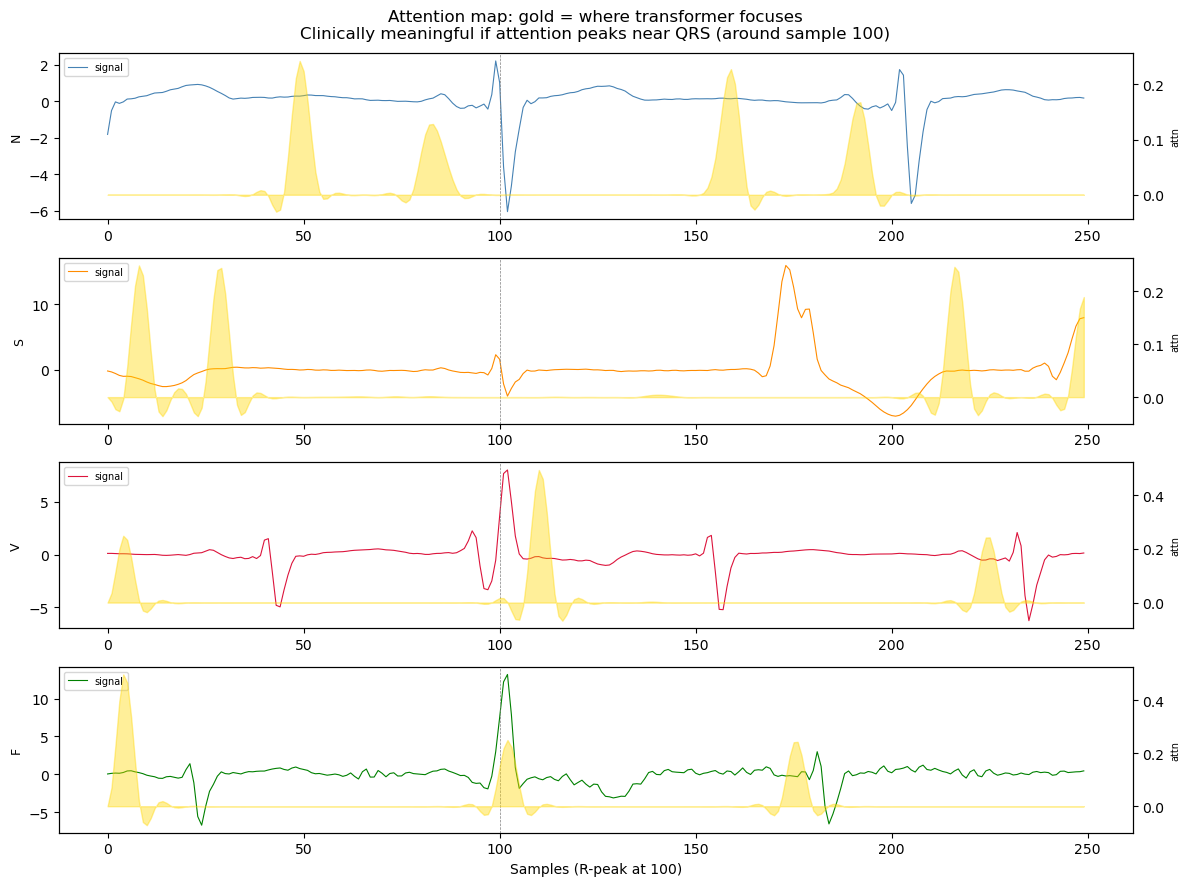

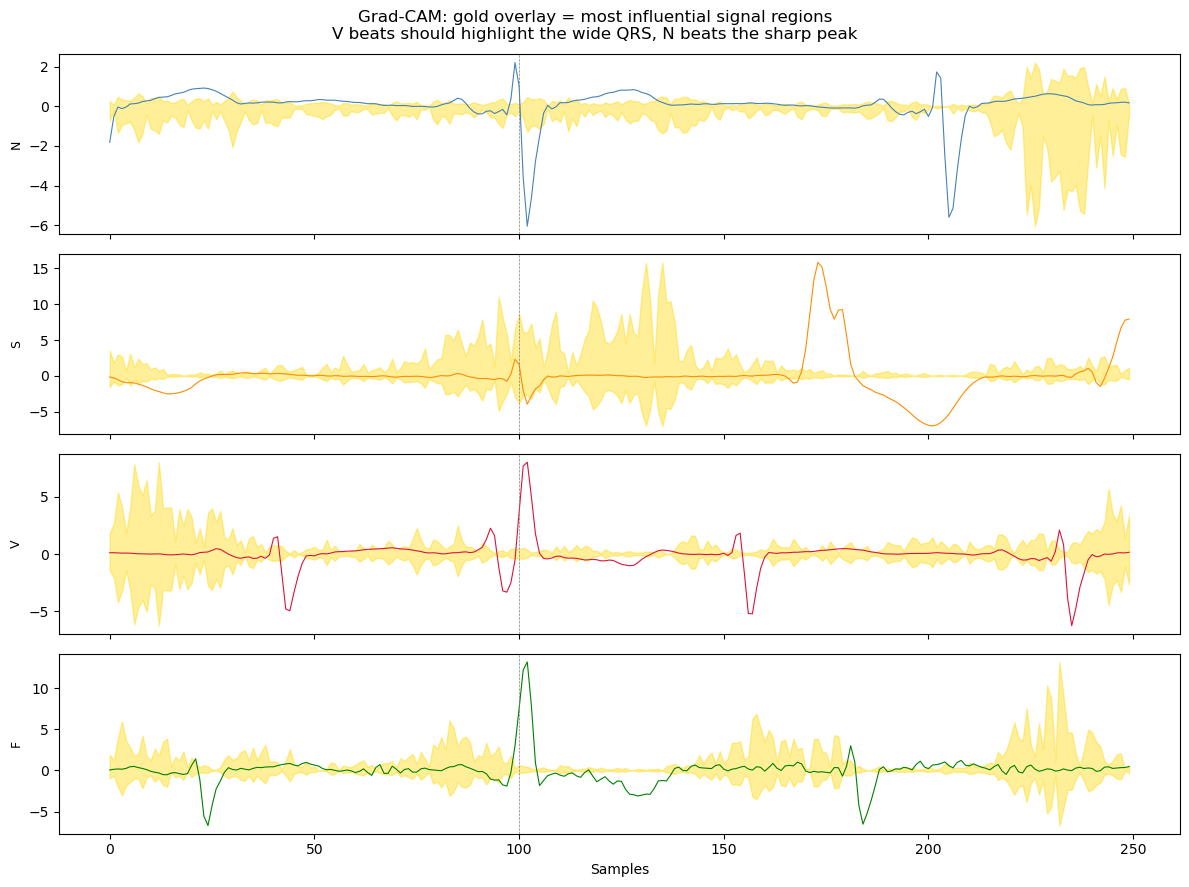

In [10]:
# WHY interpretability?
# A model can be accurate but for wrong reasons.
# If it classifies V beats correctly because of noise artifacts, not beat shape,
# it will fail on clean data from another hospital.
# We use two techniques:
#
# 1. Attention map — shows which TIME STEPS the transformer focused on.
#    If it attends to the QRS complex, that's clinically meaningful.
#    If it attends to random noise, the model is not truly learning ECG.
#
# 2. Grad-CAM — shows which input samples most influenced the prediction.
#    Gradient of the predicted class score w.r.t. input signal.
#    High gradient = "changing this sample would change the prediction most".

# --- Attention maps ---
fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=False)
names  = ["N","S","V","F"]
colors = ["steelblue","darkorange","crimson","green"]

from scipy.ndimage import zoom

for cls in range(4):
    idx    = np.where(ltdb_y == cls)[0][0]
    sample = ltdb_X[idx]
    x      = torch.tensor(sample[np.newaxis], dtype=torch.float32).to(device)
    attn   = model_ltdb.get_attn(x)                   # (T',)
    attn_up = zoom(attn, sample.shape[1] / len(attn)) # upsample to 250

    ax  = axes[cls]
    ax2 = ax.twinx()
    ax.plot(sample[0], lw=0.8, color=colors[cls], label="signal")
    ax2.fill_between(np.arange(250), attn_up,
                     alpha=0.4, color="gold", label="attention")
    ax.axvline(100, color="gray", lw=0.5, ls="--")
    ax.set_ylabel(names[cls], fontsize=9)
    ax2.set_ylabel("attn", fontsize=7)
    ax.legend(fontsize=7, loc="upper left")

axes[-1].set_xlabel("Samples (R-peak at 100)")
fig.suptitle("Attention map: gold = where transformer focuses\n"
             "Clinically meaningful if attention peaks near QRS (around sample 100)")
plt.tight_layout(); plt.show()

# --- Grad-CAM ---
fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)

for cls in range(4):
    idx    = np.where(ltdb_y == cls)[0][0]
    sample = ltdb_X[idx]
    
    # FIX: Create on device then enable grad
    x = torch.tensor(sample[np.newaxis], dtype=torch.float32).to(device)
    x.requires_grad = True 
    
    model_ltdb.eval()
    logits = model_ltdb(x)
    
    model_ltdb.zero_grad()
    logits[0, cls].backward()

    # Now x.grad will NOT be None
    cam = x.grad.detach().cpu().numpy()[0]  # (2, 250)
    cam = np.abs(cam).mean(axis=0)           # avg over leads
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

    axes[cls].plot(sample[0], lw=0.8, color=colors[cls])
    axes[cls].fill_between(np.arange(250),
                            sample[0].min() * cam,
                            sample[0].max() * cam,
                            alpha=0.4, color="gold")
    axes[cls].axvline(100, color="gray", lw=0.5, ls="--")
    axes[cls].set_ylabel(names[cls], fontsize=9)

axes[-1].set_xlabel("Samples")
fig.suptitle("Grad-CAM: gold overlay = most influential signal regions\n"
             "V beats should highlight the wide QRS, N beats the sharp peak")
plt.tight_layout(); plt.show()

  Noise σ=0.00 → Macro F1=0.940
  Noise σ=0.05 → Macro F1=0.943
  Noise σ=0.10 → Macro F1=0.941
  Noise σ=0.20 → Macro F1=0.922
  Noise σ=0.50 → Macro F1=0.674


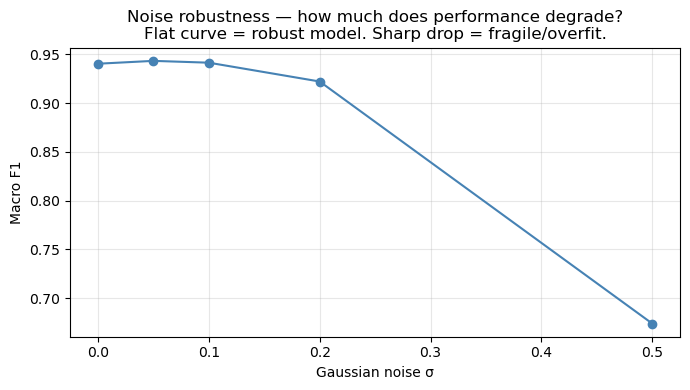

In [11]:
# GENERALIZABILITY EXPLANATION:
#
# A model that memorizes training data will fail on new patients/equipment.
# We test three ways:
#
# 1. Held-out test split — 15% of same dataset, unseen during training.
#    This is the minimum bar. Every model passes this if trained correctly.
#
# 2. Gaussian noise test — add increasing noise to test set.
#    Real-world ECGs from different equipment have different noise levels.
#    A robust model maintains performance under moderate noise.
#    A fragile model collapses immediately — it memorized noise patterns.
#
# 3. OOD test (MIT-BIH) — completely different database.
#    Different patients, different hospital, different recording equipment.
#    This is the real test of generalizability.
#    If F1 drops <15% vs in-distribution, the model is genuinely generalizable.

# --- Noise robustness ---
noise_levels = [0.0, 0.05, 0.1, 0.2, 0.5]
f1_noise = []

for std in noise_levels:
    Xn = Xte_l + np.random.randn(*Xte_l.shape).astype(np.float32) * std
    loader = DataLoader(ECGDataset(Xn, yte_l), batch_size=64, shuffle=False)
    ps, ts = [], []
    model_ltdb.eval()
    with torch.no_grad():
        for x, y in loader:
            ps.append(model_ltdb(x.to(device)).argmax(1).cpu())
            ts.append(y)
    f1 = f1_score(torch.cat(ts), torch.cat(ps), average="macro")
    f1_noise.append(f1)
    print(f"  Noise σ={std:.2f} → Macro F1={f1:.3f}")

plt.figure(figsize=(7, 4))
plt.plot(noise_levels, f1_noise, "o-", color="steelblue")
plt.xlabel("Gaussian noise σ"); plt.ylabel("Macro F1")
plt.title("Noise robustness — how much does performance degrade?\n"
          "Flat curve = robust model. Sharp drop = fragile/overfit.")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()